<a href="https://colab.research.google.com/github/mumtaza7715-ai/my_python/blob/main/regresi_tasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Library
import numpy as np
import pandas as pd
import statsmodels.api as sm
# Membuat DataFrame dari data yang diberikan
data = {
'Partisipan': np.arange(1, 11),
'PMakan': [50, 40, 60, 55, 45, 65, 70, 75, 80, 90],
'PTranspor': [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
'BB': [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]}
df = pd.DataFrame(data)
# Memisahkan variabel independen dan dependen
X = df[['PMakan', 'PTranspor']]
y = df['BB']
X = sm.add_constant(X) # Menambahkan kolom konstanta untuk intercept
model = sm.OLS(y, X) # Membangun model regresi
results = model.fit()
print(results.summary()) # Menampilkan hasil

                            OLS Regression Results                            
Dep. Variable:                     BB   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     234.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.85e-07
Time:                        00:08:36   Log-Likelihood:                -18.626
No. Observations:                  10   AIC:                             43.25
Df Residuals:                       7   BIC:                             44.16
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.9870      2.879      9.374      0.0

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.graph_objects as go

# 1. MEMBUAT DATA
data = {
    "Partisipan": np.arange(1, 11),
    "Peng Makanan": [50, 40, 60, 55, 45, 65, 70, 75, 80, 90],
    "Peng Transportasi": [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
    "Berat Badan": [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]
}

df = pd.DataFrame(data)

# 2. VARIABEL INDEPENDEN
X = df[["Peng Makanan", "Peng Transportasi"]]

# 3. VARIABEL DEPENDEN
y = df["Berat Badan"]

# 4. MENAMBAHKAN INTERCEPT
X_model = sm.add_constant(X)

# 5. ESTIMASI MODEL OLS
model = sm.OLS(y, X_model)
results = model.fit()

# 6. MENAMPILKAN HASIL REGRESI
print("\n")
print("=" * 70)
print("HASIL REGRESI LINEAR BERGANDA")
print("=" * 70)
print(results.summary())

# 7. MENGAMBIL KOEFISIEN
intercept = results.params["const"]
coef_makanan = results.params["Peng Makanan"]
coef_transportasi = results.params["Peng Transportasi"]

r_squared = results.rsquared
adjusted_r_squared = results.rsquared_adj

# 8. PERSAMAAN REGRESI
persamaan = (
    f"Ŷ = {intercept:.3f}"
    f" + ({coef_makanan:.3f})X1"
    f" + ({coef_transportasi:.3f})X2"
)

print("\n")
print("=" * 70)
print("PERSAMAAN REGRESI")
print("=" * 70)
print(persamaan)
print(f"\nR² = {r_squared:.4f}")
print(f"Adjusted R² = {adjusted_r_squared:.4f}")

# 9. MENGHITUNG PREDIKSI
df["Prediksi"] = results.predict(X_model)

print("\n")
print("=" * 70)
print("DATA AKTUAL DAN PREDIKSI")
print("=" * 70)

print(
    df[
        [
            "Partisipan",
            "Peng Makanan",
            "Peng Transportasi",
            "Berat Badan",
            "Prediksi"
        ]
    ].round(2)
)

# 10. MEMBUAT GRID BIDANG REGRESI
x1 = np.linspace(
    df["Peng Makanan"].min(),
    df["Peng Makanan"].max(),
    40
)

x2 = np.linspace(
    df["Peng Transportasi"].min(),
    df["Peng Transportasi"].max(),
    40
)

X1, X2 = np.meshgrid(x1, x2)

# 11. MENGHITUNG NILAI Y PADA BIDANG REGRESI
Y = (
    intercept
    + coef_makanan * X1
    + coef_transportasi * X2
)

# 12. MEMBUAT FIGURE
fig = go.Figure()

# 13. DATA AKTUAL
fig.add_trace(
    go.Scatter3d(
        x=df["Peng Makanan"],
        y=df["Peng Transportasi"],
        z=df["Berat Badan"],
        mode="markers",
        marker=dict(
            size=7,
            color="red",
            opacity=0.9
        ),
        name="Data Aktual",
        text=[
            f"Partisipan {p}"
            for p in df["Partisipan"]
        ],
        hovertemplate=
        "<b>%{text}</b><br>" +
        "Peng. Makanan: %{x}<br>" +
        "Peng. Transportasi: %{y}<br>" +
        "Berat Badan: %{z}" +
        "<extra></extra>"
    )
)

# 14. BIDANG REGRESI
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Y,
        opacity=0.6,
        colorscale="Viridis",
        name="Regression Plane",
        hovertemplate=
        "Peng. Makanan: %{x:.2f}<br>" +
        "Peng. Transportasi: %{y:.2f}<br>" +
        "Prediksi Y: %{z:.2f}" +
        "<extra></extra>"
    )
)

# 15. TAMPILAN GRAFIK
fig.update_layout(
    title={
        "text":
            "REGRESI LINEAR BERGANDA 3D"
            "<br>"
            f"<sup>{persamaan} | R² = {r_squared:.3f}</sup>",
        "x": 0.5
    },
    scene={
        "xaxis": {
            "title": "Pengeluaran Makanan (X1)"
        },
        "yaxis": {
            "title": "Pengeluaran Transportasi (X2)"
        },
        "zaxis": {
            "title": "Berat Badan (Y)"
        }
    },
    width=1000,
    height=750,
    margin={
        "l": 0,
        "r": 0,
        "b": 0,
        "t": 100
    },
    legend={
        "x": 0.02,
        "y": 0.98
    }
)

# 16. MENAMPILKAN GRAFIK
fig.show()



HASIL REGRESI LINEAR BERGANDA
                            OLS Regression Results                            
Dep. Variable:            Berat Badan   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     234.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.85e-07
Time:                        00:25:00   Log-Likelihood:                -18.626
No. Observations:                  10   AIC:                             43.25
Df Residuals:                       7   BIC:                             44.16
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

Test Statistic: 14.751506680126681
p-value: 0.0006262547379134614
----------------------------------------


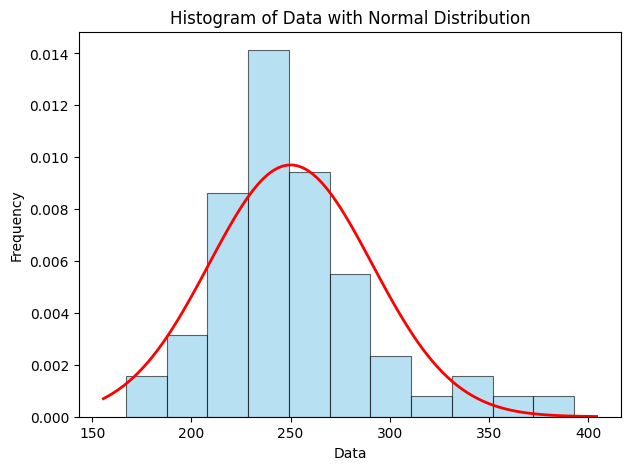

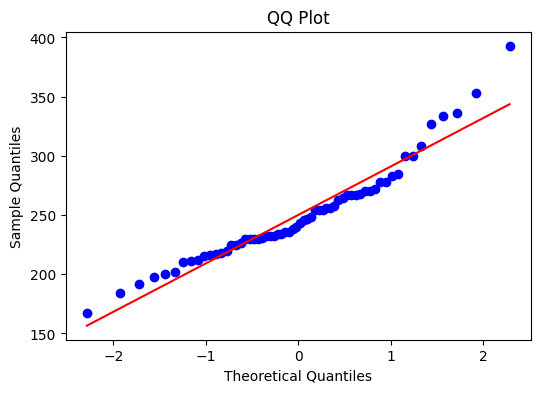

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Data lengkap 62 subjek dari Framingham Heart Study
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# 1. Uji Normalitas (Normality Test)
result = stats.normaltest(data)
test_statistic = result.statistic
p_value = result.pvalue

# Menampilkan hasil statistik
print("Test Statistic:", test_statistic)
print("p-value:", p_value)
print("-" * 40)

# 2. Plot Histogram & Kurva Distribusi Normal
plt.figure(figsize=(7, 5))
plt.hist(data, bins='auto', density=True, alpha=0.6, color='skyblue', edgecolor='black', linewidth=0.8)

# Plot kurva distribusi normal
mu, std = np.mean(data), np.std(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
y = stats.norm.pdf(x, mu, std)
plt.plot(x, y, color='red', linewidth=2)

# Mengatur judul dan label grafik
plt.title('Histogram of Data with Normal Distribution')
plt.xlabel('Data')
plt.ylabel('Frequency')
plt.show()

# 3. QQ Plot
plt.figure(figsize=(6, 4))
stats.probplot(data, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

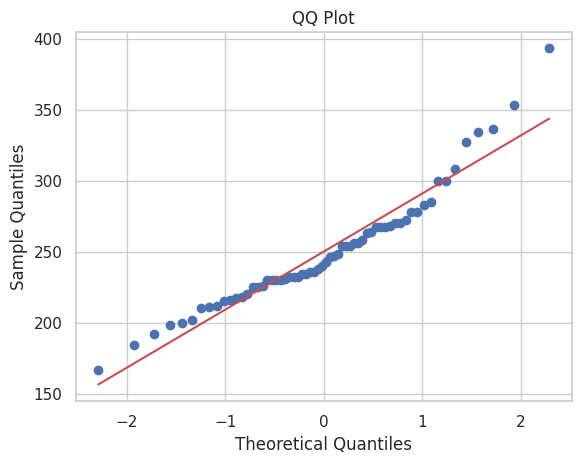

In [ ]:
import numpy as np
import seaborn as sns
import scipy.stats as stats

# Data lengkap 62 subjek dengan kurung penutup yang benar
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# Generate QQ plot
sns.set(style="whitegrid")
stats.probplot(data, dist="norm", plot=sns.mpl.pyplot)

# Set plot title and labels
sns.mpl.pyplot.title('QQ Plot')
sns.mpl.pyplot.xlabel('Theoretical Quantiles')
sns.mpl.pyplot.ylabel('Sample Quantiles')

# Show the plot
sns.mpl.pyplot.show()

In [ ]:
import numpy as np
from scipy import stats

# Data lengkap 62 subjek dengan kurung penutup yang benar
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# Kolmogorov-Smirnov Test
# Catatan: kstest pada 'norm' idealnya membandingkan data yang sudah distandarisasi (mean=0, std=1),
# namun kode di bawah mengikuti format asli Anda.
ks_statistic, ks_pvalue = stats.kstest(data, 'norm')
print("Kolmogorov-Smirnov Test:")
print("Test Statistic:", ks_statistic)
print("p-value:", ks_pvalue)

# Shapiro-Wilk Test
sw_statistic, sw_pvalue = stats.shapiro(data)
print("\nShapiro-Wilk Test:")
print("Test Statistic:", sw_statistic)
print("p-value:", sw_pvalue)

# Jarque-Bera Test
jb_statistic, jb_pvalue = stats.jarque_bera(data)
print("\nJarque-Bera Test:")
print("Test Statistic:", jb_statistic)
print("p-value:", jb_pvalue)

Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0

Shapiro-Wilk Test:
Test Statistic: 0.9385651298228793
p-value: 0.0038978835421956235

Jarque-Bera Test:
Test Statistic: 17.253454012480432
p-value: 0.00017925037145018067


UJI NORMALITAS

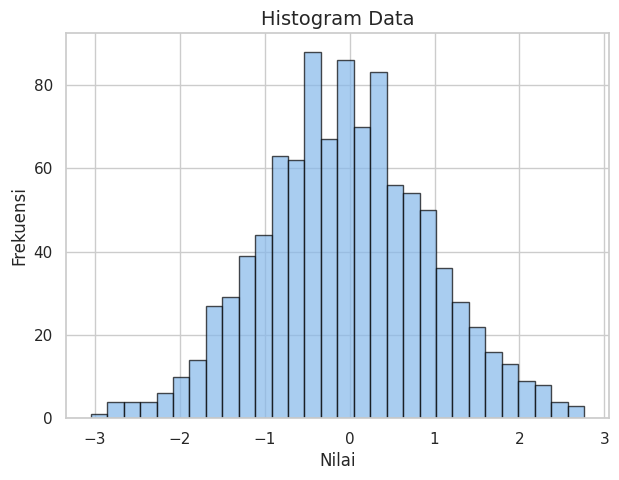

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate random data sesuai modul PDF
np.random.seed(0)
var1 = np.random.normal(0, 1, 1000)

# Hitung mean dan standar deviasi
mu, sigma = np.mean(var1), np.std(var1)

# Plot histogram
plt.figure(figsize=(7, 5))
count, bins, ignored = plt.hist(var1, bins=30, density=False, color='#85b8eb', edgecolor='black', alpha=0.7)

# Atur judul dan label agar sama persis
plt.title("Histogram Data", fontsize=14)
plt.xlabel("Nilai", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)

# Menampilkan grafik
plt.show()

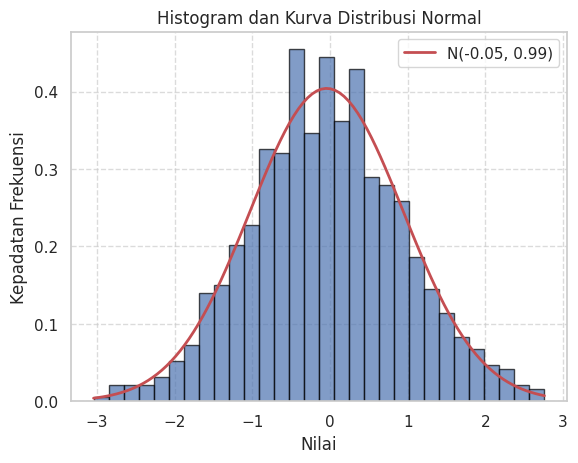

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate random data
np.random.seed(0)
tahun = np.arange(1, 11)
var1 = np.random.normal(0, 1, 1000)  # data lebih banyak agar distribusi terlihat jelas

# Hitung mean dan standar deviasi
mu, sigma = np.mean(var1), np.std(var1)

# Plot histogram
count, bins, ignored = plt.hist(
    var1,
    bins=30,
    density=True,
    edgecolor='black',
    alpha=0.7
)

# Plot kurva distribusi normal
x = np.linspace(min(bins), max(bins), 100)
pdf = norm.pdf(x, mu, sigma)

plt.plot(
    x,
    pdf,
    'r-',
    linewidth=2,
    label=f'N({mu:.2f}, {sigma:.2f})'
)

# Tambahkan label dan grid
plt.xlabel('Nilai')
plt.ylabel('Kepadatan Frekuensi')
plt.title('Histogram dan Kurva Distribusi Normal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

UJI ASUMSI KLASIK

Koefisien Regresi:
Beta0: 0.1915
Beta1: 1.9668
Beta2: 3.0571


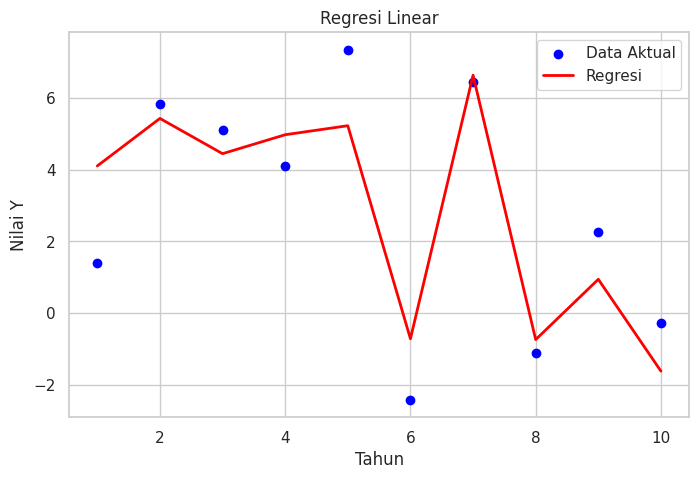

In [ ]:
# Regresi Uji Asumsi Klasik

import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(0)

tahun = np.arange(1, 11)  # Variabel independen tahun

variabel1 = np.random.normal(0, 1, 10)
variabel2 = np.random.normal(0, 1, 10)

# Variabel dependen
nilai_y = (
    2 * variabel1
    + 3 * variabel2
    + np.random.normal(0, 1, 10)
)

# Perform linear regression
X = np.column_stack((variabel1, variabel2))

# Tambahkan kolom intercept
X = np.column_stack((np.ones(len(tahun)), X))

# Hitung parameter beta
beta = np.linalg.inv(X.T @ X) @ X.T @ nilai_y

print("Koefisien Regresi:")
for i in range(len(beta)):
    print(f"Beta{i}: {beta[i]:.4f}")

# Prediksi
y_pred = X @ beta

# Plot data dan regresi
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    tahun,
    nilai_y,
    color='blue',
    label='Data Aktual'
)

ax.plot(
    tahun,
    y_pred,
    color='red',
    linewidth=2,
    label='Regresi'
)

ax.set_xlabel('Tahun')
ax.set_ylabel('Nilai Y')
ax.set_title('Regresi Linear')
ax.legend()

plt.grid(True)
plt.show()